# Model Diagnostics

### Verifying Project Root

In [9]:
import sys
from pathlib import Path

# find project root (one level above notebooks/)
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


### Imports & Data Loading

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modeling.splits import make_time_split, filter_countries_min_years
from modeling.pipelines import build_preprocessor, build_model_pipeline
from modeling.baselines import ridge_cv
from modeling.train_eval import train_eval
from analysis.diagnostics import (
    plot_predicted_vs_actual, plot_residuals_vs_predicted, plot_residual_hist,
    worst_errors_table, group_error_table, time_slice_error_table
)

RANDOM_SEED = 42
TARGET = "life_expectancy"
YEAR_COL = "year"

df = pd.read_csv("../data/processed/main_dataset.csv")
df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="raise").astype(int)

### Recreating Feature Logic from Notebook 06

In [11]:
leakage_cols = ["life_expectancy", "life_expectancy_wb"]
id_cols = ["country", "country_code"]
group_cols = ["region", "income_group"]

model_df = df.dropna(subset=[TARGET]).copy()
X_df = model_df.drop(columns=[TARGET], errors="ignore").copy()
X_df = X_df.drop(columns=[c for c in leakage_cols if c in X_df.columns], errors="ignore")
X_df = X_df.drop(columns=[c for c in id_cols if c in X_df.columns], errors="ignore")

KEEP_YEAR = True
if not KEEP_YEAR and YEAR_COL in X_df.columns:
    X_df = X_df.drop(columns=[YEAR_COL])

if "status" in X_df.columns:
    X_df["status_flag"] = (X_df["status"].astype(str).str.lower().str.contains("developed")).astype(int)
    X_df = X_df.drop(columns=["status"])

final_df = X_df.copy()
final_df[TARGET] = model_df[TARGET].values

# attach ids for diagnosis
for c in ["country", "country_code", "region", "income_group", YEAR_COL]:
    if c in model_df.columns and c not in final_df.columns:
        final_df[c] = model_df[c].values

final_df.shape

(2265, 34)

### Feature Set

In [21]:
# load reduced feature list saved in 06 (recommended)
with open("../outputs/metrics/final_features_reduced.json", "r") as f:
    FEATURES = json.load(f)

FEATURES, len(FEATURES)

(['year',
  'adult_mortality',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'under_five_deaths',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'gdp',
  'population',
  'thinness_1_19_years',
  'income_composition_of_resources',
  'schooling',
  'undernourishment',
  'co2',
  'health_expenditure_percent',
  'education_expenditure_percent',
  'unemployment',
  'sanitation',
  'injuries',
  'communicable',
  'noncommunicable_disease',
  'status_flag'],
 27)

## Time split + fit RidgeCV + prediction df with IDs

In [14]:
balanced_df = filter_countries_min_years(final_df, min_years=5)

X_train, X_test, y_train, y_test, info = make_time_split(
    balanced_df, target_col=TARGET, year_col=YEAR_COL, test_years=3
)

Xtr = X_train[FEATURES].copy()
Xte = X_test[FEATURES].copy()

num_cols = Xtr.select_dtypes(include=["number"]).columns.tolist()
cat_cols = Xtr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

pre = build_preprocessor(num_cols, cat_cols, scale_numeric=True)
pipe = build_model_pipeline(ridge_cv(), pre)

# attach IDs from balanced_df for the test subset
id_df = balanced_df.loc[X_test.index, ["country", "region", "income_group", YEAR_COL]].copy()

res, pred_df = train_eval(
    pipe, Xtr, y_train, Xte, y_test,
    model_name="RidgeCV", split_name="time_reduced",
    return_predictions_df=True,
    id_df=id_df,
    id_cols=["country","region","income_group",YEAR_COL]
)
res

EvalResult(model_name='RidgeCV', split_name='time_reduced', n_train=1812, n_test=453, rmse=3.154713546321192, mae=2.523853708056834, r2=0.8579876112907525)

### Predicted vs Actual

<Figure size 640x480 with 0 Axes>

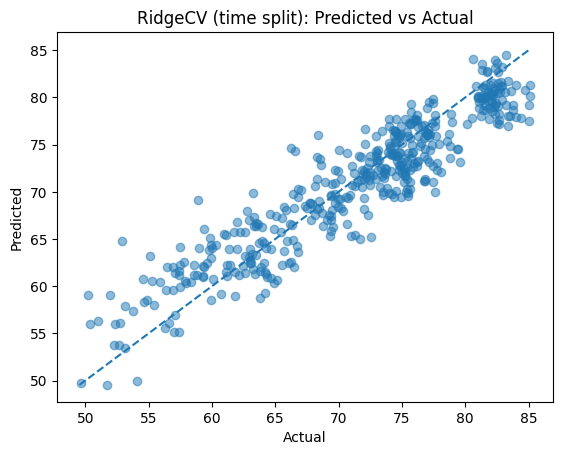

In [15]:
plt.figure()
plot_predicted_vs_actual(pred_df["y_true"], pred_df["y_pred"], title="RidgeCV (time split): Predicted vs Actual")
plt.show()

### Residuals vs Predicted

<Figure size 640x480 with 0 Axes>

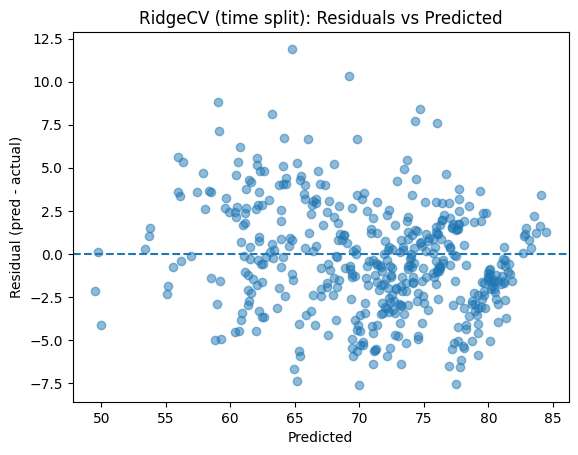

In [16]:
plt.figure()
plot_residuals_vs_predicted(pred_df["y_true"], pred_df["y_pred"], title="RidgeCV (time split): Residuals vs Predicted")
plt.show()

### Residual Histogram

<Figure size 640x480 with 0 Axes>

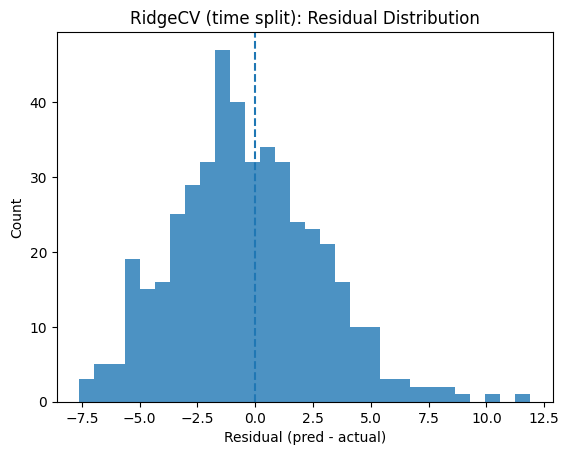

In [17]:
plt.figure()
plot_residual_hist(pred_df["y_true"], pred_df["y_pred"], title="RidgeCV (time split): Residual Distribution")
plt.show()

### Table: Worst Errors

In [18]:
worst_errors_table(pred_df, n=10)

,country,year,region,income_group,y_true,y_pred,error,abs_error
371,Sierra Leone,2013,Sub-Saharan Africa,Low income,52.865500,64.762558,11.897058,11.897058
71,Burundi,2013,Sub-Saharan Africa,Low income,58.874000,69.180547,10.306547,10.306547
370,Sierra Leone,2014,Sub-Saharan Africa,Low income,50.236000,59.027482,8.791482,8.791482
224,Kiribati,2013,East Asia & Pacific,Lower middle income,66.245000,74.683194,8.438194,8.438194
287,Mozambique,2013,Sub-Saharan Africa,Low income,55.124500,63.253070,8.128570,8.128570
223,Kiribati,2014,East Asia & Pacific,Lower middle income,66.547500,74.280317,7.732817,7.732817
139,Fiji,2014,East Asia & Pacific,Upper middle income,68.365000,75.981462,7.616462,7.616462
322,Panama,2014,Latin America & Caribbean,High income,77.591500,69.987957,-7.603543,7.603543
340,Portugal,2014,Europe & Central Asia,High income,85.060976,77.525621,-7.535354,7.535354
165,Guatemala,2015,Latin America & Caribbean,Upper middle income,72.575000,65.183569,-7.391431,7.391431


### Table: Error by Region

In [23]:
from IPython.display import display

if "region" in pred_df.columns:
    display(group_error_table(pred_df, "region").head(15))
else:
    print("region not in pred_df columns")

,region,n,mae,rmse
5,South Asia,24,3.267172,3.883063
6,Sub-Saharan Africa,123,2.990687,3.683060
4,North America,3,2.607579,2.887905
2,Latin America & Caribbean,78,2.520916,3.104373
0,East Asia & Pacific,57,2.458479,3.240205
1,Europe & Central Asia,120,2.229505,2.688435
3,Middle East & North Africa,48,1.768980,2.215075


### Table: Error by Year

In [24]:
if YEAR_COL in pred_df.columns:
    display(time_slice_error_table(pred_df, year_col=YEAR_COL))
else:
    print(f"{YEAR_COL} not in pred_df columns")

,year,n,mae,rmse
0,2013,151,2.494328,3.192759
1,2014,151,2.617508,3.272934
2,2015,151,2.459725,2.991797
